# Import libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dataset Loading & Overview

In [16]:
df=pd.read_csv("AAPL.csv")

In [17]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [18]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
10404,2022-03-18,160.509995,164.479996,159.759995,163.979996,163.979996,123351200
10405,2022-03-21,163.509995,166.350006,163.009995,165.380005,165.380005,95811400
10406,2022-03-22,165.509995,169.419998,164.910004,168.820007,168.820007,81532000
10407,2022-03-23,167.990005,172.639999,167.649994,170.210007,170.210007,98062700
10408,2022-03-24,171.059998,174.139999,170.210007,174.070007,174.070007,90018700


In [19]:
df.shape

(10409, 7)

# Exploratory Data Analysis

In [20]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

# Data Preprocessing

In [22]:
df1=df.reset_index()['Close']
df1.head()

0    0.128348
1    0.121652
2    0.112723
3    0.115513
4    0.118862
Name: Close, dtype: float64

In [23]:
df1.shape

(10409,)

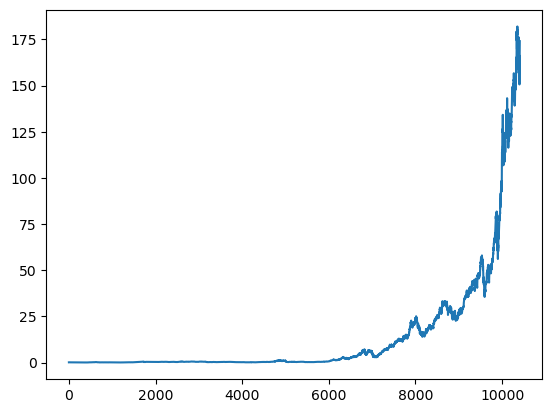

In [24]:
plt.plot(df1)

# MinMax Scaler (Standardization)

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [26]:
df1.shape

(10409, 1)

In [29]:
print(df1)

[[4.35483696e-04]
 [3.98684579e-04]
 [3.49613594e-04]
 ...
 [9.27511961e-01]
 [9.35150965e-01]
 [9.56364315e-01]]


# Train-Test Split

In [30]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df1, test_size=0.35, shuffle=False)

In [32]:
train_data.shape, test_data.shape

((6765, 1), (3644, 1))

# Create Sliding Window

In [33]:
def create_dataset(dataset, time_step=1):
    X = [dataset[i:i+time_step, 0] for i in range(len(dataset)-time_step-1)]
    y = [dataset[i+time_step, 0] for i in range(len(dataset)-time_step-1)]
    return np.array(X), np.array(y)

In [34]:
time_step=100
X_train,y_train=create_dataset(train_data,time_step)
X_test,y_test=create_dataset(test_data,time_step)

In [35]:
print(X_train)

[[0.00043548 0.00039868 0.00034961 ... 0.00042322 0.00042015 0.00040175]
 [0.00039868 0.00034961 0.00036495 ... 0.00042015 0.00040175 0.00041095]
 [0.00034961 0.00036495 0.00038335 ... 0.00040175 0.00041095 0.00041708]
 ...
 [0.02035073 0.02070794 0.02079823 ... 0.02979545 0.02971498 0.03005454]
 [0.02070794 0.02079823 0.02107301 ... 0.02971498 0.03005454 0.02985237]
 [0.02079823 0.02107301 0.0211947  ... 0.03005454 0.02985237 0.03041568]]


In [36]:
print(y_train)

[0.00041095 0.00041708 0.00040175 ... 0.02985237 0.03041568 0.03082982]


In [37]:
print(X_test)

[[0.03039605 0.03141864 0.03268658 ... 0.02323204 0.02311623 0.02386404]
 [0.03141864 0.03268658 0.03267676 ... 0.02311623 0.02386404 0.02522815]
 [0.03268658 0.03267676 0.03246675 ... 0.02386404 0.02522815 0.02426836]
 ...
 [0.82034607 0.8177631  0.83820705 ... 0.87678671 0.88244727 0.90091278]
 [0.8177631  0.83820705 0.82298398 ... 0.88244727 0.90091278 0.90860679]
 [0.83820705 0.82298398 0.81836763 ... 0.90091278 0.90860679 0.92751196]]


In [38]:
print(y_test)

[0.02522815 0.02426836 0.02362262 ... 0.90860679 0.92751196 0.93515096]


In [40]:
X_train.shape, y_train.shape

((6664, 100), (6664,))

In [41]:
X_test.shape, y_test.shape

((3543, 100), (3543,))

# Reshape input for LSTM

In [42]:
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test=X_test.reshape(X_test.shape[0],X_test.shape[1],1)

# Model Training (Stacked LSTM)

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [44]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

C:\Users\aryan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 50)             │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 238ms/step - loss: 1.3819e-05 - val_loss: 0.0063
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 218ms/step - loss: 2.7048e-07 - val_loss: 0.0056
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - loss: 4.2899e-07 - val_loss: 0.0067
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 223ms/step - loss: 3.7616e-07 - val_loss: 0.0057
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step - loss: 2.4629e-07 - val_loss: 0.0047
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - loss: 2.9738e-07 - val_loss: 0.0047
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 222ms/step - loss: 2.1814e-07 - val_loss: 0.0047
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 222ms/step - loss: 2.4196e-07 - val_loss: 0.0036
Epoch 9/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 225ms/step - loss: 2.2551e-07 - val_loss: 0.0041
Epoch 10/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 225ms/step - loss: 2.0288e-07 - val_loss: 0.0041
Epoch 11/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 224ms/step - 

# Predict and Evaluate

In [48]:
train_predict= model.predict(X_train)
test_predict= model.predict(X_test)

209/209 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step


In [49]:
train_predict= scaler.inverse_transform(train_predict)
test_predict= scaler.inverse_transform(test_predict)

In [51]:
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

0.9387362012815346

In [52]:
math.sqrt(mean_squared_error(y_test,test_predict))

48.955000377657285

# Plot

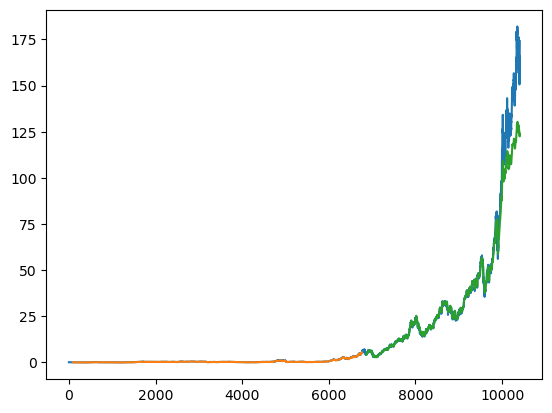

In [53]:
look_back = 100

train_plot = np.full_like(df1, np.nan)
test_plot = np.full_like(df1, np.nan)

train_plot[look_back:look_back + len(train_predict)] = train_predict
test_plot[len(train_predict) + (look_back*2) + 1 : len(df1) - 1] = test_predict

plt.plot(scaler.inverse_transform(df1))
plt.plot(train_plot)
plt.plot(test_plot)
plt.show()